In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(PROJECT_ROOT)

d:\Property Intelligence Platform


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
from src.data.ingestion import load_data

df = load_data("../data/feature_engineered/gurgaon_properties_missing_value_imputation.csv")


Dataset loaded successfully.
Rows: 3553
Columns: 18


In [4]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,sare crescent parc royal greens phase 1,sector 92,0.85,4877.0,4,4,3,4.0,Relatively New,1743.0,0,0,0,0,0,0,0
1,flat,sare green parc phase 3,sector 92,1.08,5150.0,4,4,2,16.0,New Property,1891.0,0,1,0,0,0,0,107
2,house,unitech uniworld resorts,sector 33,8.00,11429.0,4,4,3+,2.0,Old Property,7000.0,1,1,1,1,0,0,77
3,flat,ireo the corridors,sector 67a,1.60,9265.0,3,3,2,3.0,New Property,1346.0,0,0,1,0,0,1,142
4,house,rwa sector 46,sector 46,4.50,24390.0,6,6,3+,3.0,Moderately Old,1845.0,0,0,1,0,0,1,80


In [5]:
from src.data.ingestion import load_data

latlong  = load_data("../data/coordinates/latlong.csv")


Dataset loaded successfully.
Rows: 129
Columns: 2


In [6]:
latlong.head()

,sector,coordinates
0,sector 1,"28.3663° N, 76.9456° E"
1,sector 2,"28.5095° N, 77.0320° E"
2,sector 3,"28.4909° N, 77.0176° E"
3,sector 4,"28.4738° N, 77.0107° E"
4,sector 5,"28.4794° N, 77.0176° E"


In [7]:
latlong['latitude'] = latlong['coordinates'].str.split(',').str.get(0).str.split('°').str.get(0).astype('float')
latlong['longitude'] = latlong['coordinates'].str.split(',').str.get(1).str.split('°').str.get(0).astype('float')

In [8]:
latlong.head()

,sector,coordinates,latitude,longitude
0,sector 1,"28.3663° N, 76.9456° E",28.3663,76.9456
1,sector 2,"28.5095° N, 77.0320° E",28.5095,77.0320
2,sector 3,"28.4909° N, 77.0176° E",28.4909,77.0176
3,sector 4,"28.4738° N, 77.0107° E",28.4738,77.0107
4,sector 5,"28.4794° N, 77.0176° E",28.4794,77.0176


In [9]:
new_df = df.merge(latlong, on='sector')

In [10]:
new_df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft',
       'bedRoom', 'bathroom', 'balcony', 'floorNum', 'agePossession',
       'built_up_area', 'study room', 'servant room', 'store room',
       'pooja room', 'others', 'furnishing_type', 'luxury_score',
       'coordinates', 'latitude', 'longitude'],
      dtype='object')

In [ ]:
group_df = (
    new_df
    .groupby('sector')[[
        'price',
        'price_per_sqft',
        'built_up_area',
        'latitude',
        'longitude'
    ]]
    .mean()
)

In [12]:
group_df.head()

,price,price_per_sqft,built_up_area,latitude,longitude
sector,,,,,
gwal pahari,3.192222,9585.777778,3056.166667,28.4484,77.0210
manesar,0.962258,4608.064516,2027.367742,28.3515,76.9428
sector 1,1.860000,8249.833333,2327.833333,28.3663,76.9456
sector 102,1.696636,10603.822430,1556.130841,28.4750,76.9715
sector 103,1.495000,7445.785714,1865.428571,28.4949,76.9845


In [13]:
fig = px.scatter_mapbox(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size='built_up_area',
                  color_continuous_scale=px.colors.cyclical.IceFire, zoom=10,
                  mapbox_style="open-street-map",text=group_df.index)
fig.show()

C:\Users\user\AppData\Local\Temp\ipykernel_3964\860414701.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size='built_up_area',


In [14]:
# Create the folder if it doesn't exist
os.makedirs("../data/coordinates", exist_ok=True)

new_df.to_csv("../data/coordinates/data_viz1.csv", index=False)

print(" With coordinates  dataset saved successfully!")

 With coordinates  dataset saved successfully!


In [17]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path().resolve().parent
ARTIFACT_PATH = (
    BASE_DIR
    / "artifacts"
    / "data_viz1.pkl"
)

new_df.to_pickle(ARTIFACT_PATH)

print("Created:", ARTIFACT_PATH)
print("Shape:", new_df.shape)

Created: D:\Property Intelligence Platform\artifacts\data_viz1.pkl
Shape: (3292, 21)


In [23]:
from src.data.ingestion import load_data

df1 = load_data("../data/merged/gurgaon_properties.csv")


Dataset loaded successfully.
Rows: 3961
Columns: 20


In [24]:
df1.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating
0,4 Bedroom House for sale in Sector 92 Gurgaon,house,sare crescent parc royal greens phase 1,0.85,4877.0,1743.0,Built Up area: 1743 (161.93 sq.m.),4,4,3,not available,"Sec -92 Gurgaon, Sector 92 Gurgaon, Gurgaon, H...",4.0,NaN,undefined,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. ...",4bhk penthouse for new property in sare cresce...,"['1 Light', 'No AC', 'No Bed', 'No Chimney', '...",NaN,"['Environment5 out of 5', 'Lifestyle4 out of 5..."
1,4 BHK Flat in Sector 92 Gurgaon,flat,sare green parc phase 3,1.08,5150.0,2097.0,Super Built up area 2090(194.17 sq.m.),4,4,2,servant room,NaN,16.0,NaN,0 to 1 Year Old,"['Huda Metro Station', 'Sector Road', 'Delhi-J...",Only end user and buyers to contact. Flat in r...,NaN,"['Security / Fire Alarm', 'Intercom Facility',...","['Safety3 out of 5', 'Lifestyle4 out of 5', 'E..."
2,4 Bedroom House for sale in Sector 33 Gurgaon,house,unitech uniworld resorts,8.00,11428.0,7000.0,Plot area 7000(650.32 sq.m.),4,4,3+,"pooja room,servant room,study room,store room","Sector 33 Gurgaon, Gurgaon, Haryana",2.0,West,10+ Year Old,"['Rajiv Chowk Mosque', 'Icici bank ATM', 'Stan...",Why buy in unitech the villas?\nJust minutes a...,NaN,"['Private Garden / Terrace', 'False Ceiling Li...","['Environment3 out of 5', 'Safety4 out of 5', ..."
3,3 BHK Flat in Sector 67A Gurgaon,flat,ireo the corridors,1.60,9264.0,1727.0,Super Built up area 1727(160.44 sq.m.)Carpet a...,3,3,2,store room,"000, Sector 67A Gurgaon, Gurgaon, Haryana",3.0,North,0 to 1 Year Old,"['Huda Metro Station (Gurugram)', 'Paras Trini...",Brokers please excuse\n3 bhk +store room resid...,"['3 Wardrobe', '1 Water Purifier', '4 Fan', '1...","['Water purifier', 'Security / Fire Alarm', 'P...","['Environment5 out of 5', 'Lifestyle4 out of 5..."
4,6 Bedroom House for sale in Sector 46 Gurgaon,house,rwa sector 46,4.50,24390.0,1845.0,Plot area 204(170.57 sq.m.)Built Up area: 206 ...,6,6,3+,store room,"8 Marla Built Up As Bmt, Gf,ff, 6bhk Demand-4....",3.0,North-East,5 to 10 Year Old,"['Axis bank ATM', 'State bank of india ATM', '...",Looking for a independent house in gurgaon's p...,"['5 Wardrobe', '1 Water Purifier', '13 Fan', '...","['Private Garden / Terrace', 'High Ceiling Hei...","['Environment4 out of 5', 'Safety4 out of 5', ..."


In [25]:
wordcloud_df = df1.merge(df, left_index=True, right_index=True)[['features','sector']]

In [26]:
wordcloud_df.head()

,features,sector
0,NaN,sector 92
1,"['Security / Fire Alarm', 'Intercom Facility',...",sector 92
2,"['Private Garden / Terrace', 'False Ceiling Li...",sector 33
3,"['Water purifier', 'Security / Fire Alarm', 'P...",sector 67a
4,"['Private Garden / Terrace', 'High Ceiling Hei...",sector 46


In [27]:
import ast
main = []
for item in wordcloud_df['features'].dropna().apply(ast.literal_eval):
    main.extend(item)

In [28]:
main

['Security / Fire Alarm',
 'Intercom Facility',
 'Lift(s)',
 'Maintenance Staff',
 'Water Storage',
 'Separate entry for servant room',
 'No open drainage around',
 'Bank Attached Property',
 'Visitor Parking',
 'Swimming Pool',
 'Park',
 'Security Personnel',
 'Natural Light',
 'Airy Rooms',
 'Shopping Centre',
 'Fitness Centre / GYM',
 'Waste Disposal',
 'Rain Water Harvesting',
 'Club house / Community Center',
 'Private Garden / Terrace',
 'False Ceiling Lighting',
 'Separate entry for servant room',
 'No open drainage around',
 'Bank Attached Property',
 'Visitor Parking',
 'Swimming Pool',
 'Park',
 'Security Personnel',
 'Internet/wi-fi connectivity',
 'Low Density Society',
 'Fitness Centre / GYM',
 'Club house / Community Center',
 'Water purifier',
 'Security / Fire Alarm',
 'Power Back-up',
 'Feng Shui / Vaastu Compliant',
 'Intercom Facility',
 'Lift(s)',
 'High Ceiling Height',
 'Maintenance Staff',
 'Water Storage',
 'No open drainage around',
 'Bank Attached Property',
 

In [29]:
from wordcloud import WordCloud

In [30]:
feature_text = ' '.join(main)

In [31]:
feature_text

'Security / Fire Alarm Intercom Facility Lift(s) Maintenance Staff Water Storage Separate entry for servant room No open drainage around Bank Attached Property Visitor Parking Swimming Pool Park Security Personnel Natural Light Airy Rooms Shopping Centre Fitness Centre / GYM Waste Disposal Rain Water Harvesting Club house / Community Center Private Garden / Terrace False Ceiling Lighting Separate entry for servant room No open drainage around Bank Attached Property Visitor Parking Swimming Pool Park Security Personnel Internet/wi-fi connectivity Low Density Society Fitness Centre / GYM Club house / Community Center Water purifier Security / Fire Alarm Power Back-up Feng Shui / Vaastu Compliant Intercom Facility Lift(s) High Ceiling Height Maintenance Staff Water Storage No open drainage around Bank Attached Property Piped-gas Internet/wi-fi connectivity Visitor Parking Swimming Pool Park Security Personnel Natural Light Airy Rooms Spacious Interiors Low Density Society Waste Disposal R

In [33]:
from pathlib import Path
import pickle

BASE_DIR = Path.cwd().parent

ARTIFACT_PATH = BASE_DIR / "artifacts" / "WordCloud_feature_text.pkl"

with open(ARTIFACT_PATH, "wb") as f:
    pickle.dump(feature_text, f)

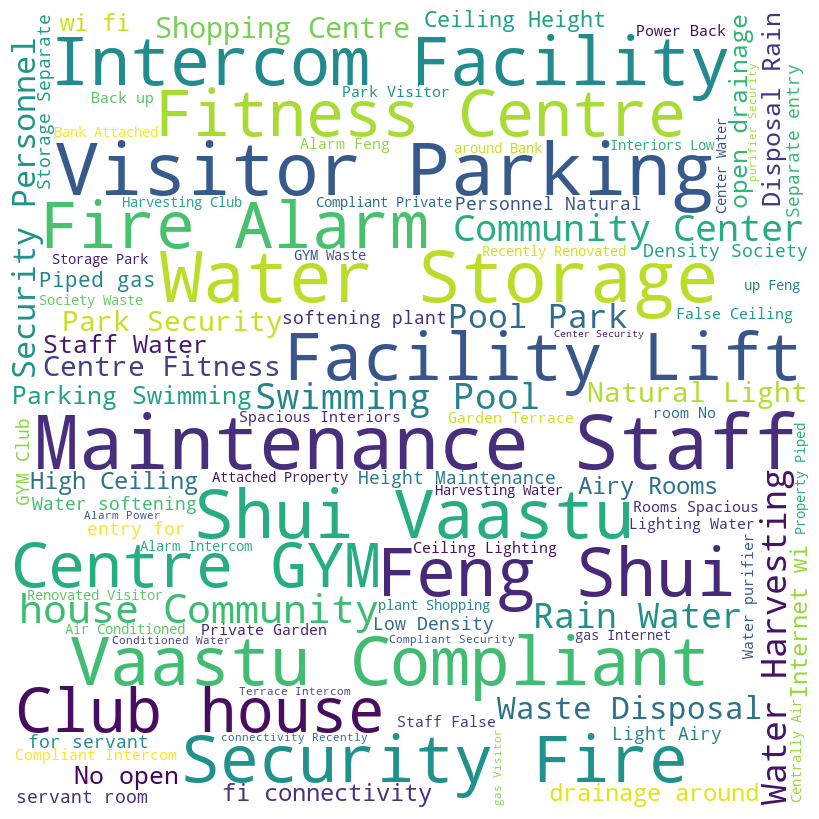

In [35]:
plt.rcParams["font.family"] = "Arial"

wordcloud = WordCloud(width = 800, height = 800, 
                      background_color ='white', 
                      stopwords = set(['s']),  # Any stopwords you'd like to exclude
                      min_font_size = 10).generate(feature_text)

plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud, interpolation='bilinear') 
plt.axis("off") 
plt.tight_layout(pad = 0) 
plt.show() # st.pyplot()

In [34]:
fig = px.scatter(df, x="built_up_area", y="price", color="bedRoom", title="Area Vs Price")

# Show the plot
fig.show()

In [37]:
temp_df = df[df['bedRoom'] <= 4]
# Create side-by-side boxplots of the total bill amounts by day
fig = px.box(temp_df, x='bedRoom', y='price', title='BHK Price Range')

# Show the plot
fig.show()

C:\Users\user\AppData\Local\Temp\ipykernel_15836\3761596323.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


C:\Users\user\AppData\Local\Temp\ipykernel_15836\3761596323.py:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='price', ylabel='Density'>

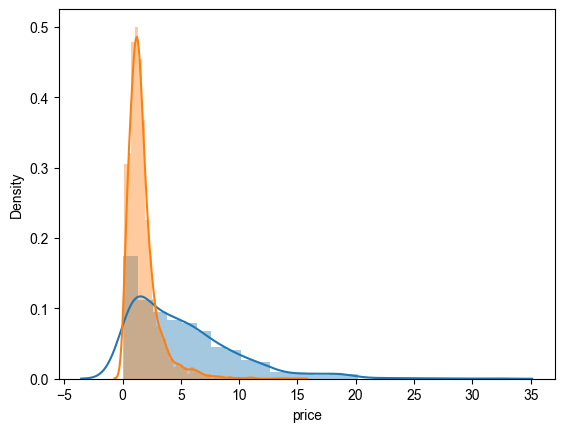

In [38]:
sns.distplot(df[df['property_type'] == 'house']['price'])
sns.distplot(df[df['property_type'] == 'flat']['price'])